In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
uploaded = files.upload()

Saving Retail_Sales_Forecasting_Dataset.xlsx to Retail_Sales_Forecasting_Dataset.xlsx


In [ ]:
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name, sheet_name="Sales_Data")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1000, 19)


In [ ]:
df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Product_Name,Category,Sub_Category,Region,Quantity,Unit_Price,Discount,Sales,Profit,Payment_Method,Year,Month,Month_Number,Quarter,Profit_Margin
0,ORD100707,2024-01-03,Customer_203,Small Business,Backpack,Bags,Travel Bags,North,8,1693.22,0.15,11513.90,2297.36,Net Banking,2024,January,1,Q1,19.95
1,ORD100420,2024-01-03,Customer_132,Small Business,Headphones,Electronics,Accessories,West,6,6104.64,0.10,32965.06,6180.10,Cash,2024,January,1,Q1,18.75
2,ORD100693,2024-01-04,Customer_211,Consumer,Shoes,Fashion,Footwear,West,10,2880.42,0.00,28804.20,8285.16,Credit Card,2024,January,1,Q1,28.76
3,ORD100350,2024-01-05,Customer_161,Corporate,Watch,Fashion,Accessories,South,4,8124.68,0.10,29248.85,9937.31,Debit Card,2024,January,1,Q1,33.98
4,ORD100012,2024-01-05,Customer_015,Corporate,Laptop,Electronics,Computers,South,10,62079.55,0.10,558715.95,128376.97,Cash,2024,January,1,Q1,22.98


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          1000 non-null   object        
 1   Order_Date        1000 non-null   datetime64[ns]
 2   Customer_Name     1000 non-null   object        
 3   Customer_Segment  1000 non-null   object        
 4   Product_Name      1000 non-null   object        
 5   Category          1000 non-null   object        
 6   Sub_Category      1000 non-null   object        
 7   Region            1000 non-null   object        
 8   Quantity          1000 non-null   int64         
 9   Unit_Price        1000 non-null   float64       
 10  Discount          1000 non-null   float64       
 11  Sales             1000 non-null   float64       
 12  Profit            1000 non-null   float64       
 13  Payment_Method    1000 non-null   object        
 14  Year              1000 no

In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Order_ID            0
Order_Date          0
Customer_Name       0
Customer_Segment    0
Product_Name        0
Category            0
Sub_Category        0
Region              0
Quantity            0
Unit_Price          0
Discount            0
Sales               0
Profit              0
Payment_Method      0
Year                0
Month               0
Month_Number        0
Quarter             0
Profit_Margin       0
dtype: int64


In [ ]:
print("Number of duplicate records:", df.duplicated().sum())

Number of duplicate records: 0


In [ ]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

print(df["Order_Date"].dtype)

datetime64[ns]


In [ ]:
df["Year"] = df["Order_Date"].dt.year
df["Month_Number"] = df["Order_Date"].dt.month
df["Month"] = df["Order_Date"].dt.month_name()
df["Quarter"] = "Q" + df["Order_Date"].dt.quarter.astype(str)
df["Day"] = df["Order_Date"].dt.day
df["Day_of_Week"] = df["Order_Date"].dt.day_name()

df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Product_Name,Category,Sub_Category,Region,Quantity,Unit_Price,...,Sales,Profit,Payment_Method,Year,Month,Month_Number,Quarter,Profit_Margin,Day,Day_of_Week
0,ORD100707,2024-01-03,Customer_203,Small Business,Backpack,Bags,Travel Bags,North,8,1693.22,...,11513.90,2297.36,Net Banking,2024,January,1,Q1,19.95,3,Wednesday
1,ORD100420,2024-01-03,Customer_132,Small Business,Headphones,Electronics,Accessories,West,6,6104.64,...,32965.06,6180.10,Cash,2024,January,1,Q1,18.75,3,Wednesday
2,ORD100693,2024-01-04,Customer_211,Consumer,Shoes,Fashion,Footwear,West,10,2880.42,...,28804.20,8285.16,Credit Card,2024,January,1,Q1,28.76,4,Thursday
3,ORD100350,2024-01-05,Customer_161,Corporate,Watch,Fashion,Accessories,South,4,8124.68,...,29248.85,9937.31,Debit Card,2024,January,1,Q1,33.98,5,Friday
4,ORD100012,2024-01-05,Customer_015,Corporate,Laptop,Electronics,Computers,South,10,62079.55,...,558715.95,128376.97,Cash,2024,January,1,Q1,22.98,5,Friday


In [ ]:
df.describe()

,Order_Date,Quantity,Unit_Price,Discount,Sales,Profit,Year,Month_Number,Profit_Margin,Day
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2024-12-29 20:16:47.999999744,5.526000,16912.686850,0.099850,82912.351780,19239.837090,2024.494000,6.531000,23.448480,16.193000
min,2024-01-03 00:00:00,1.000000,579.240000,0.000000,665.780000,161.030000,2024.000000,1.000000,12.060000,1.000000
25%,2024-06-28 18:00:00,3.000000,2420.815000,0.050000,9963.052500,2157.847500,2024.000000,4.000000,17.597500,9.000000
50%,2024-12-28 12:00:00,5.000000,5864.695000,0.100000,25671.005000,5728.845000,2024.000000,7.000000,23.670000,16.500000
75%,2025-06-25 06:00:00,8.000000,18727.087500,0.150000,79312.007500,18713.670000,2025.000000,9.250000,29.265000,24.000000
max,2025-12-31 00:00:00,10.000000,84032.280000,0.200000,819268.700000,234499.740000,2025.000000,12.000000,34.990000,31.000000
std,NaN,2.943125,23017.401234,0.071152,135561.710923,32351.611579,0.500214,3.426482,6.665927,8.797792


In [ ]:
print("Products:")
print(df["Product_Name"].unique())

print("\nCategories:")
print(df["Category"].unique())

print("\nRegions:")
print(df["Region"].unique())

print("\nCustomer Segments:")
print(df["Customer_Segment"].unique())

Products:
['Backpack' 'Headphones' 'Shoes' 'Watch' 'Laptop' 'T-Shirt' 'Smartphone'
 'Keyboard' 'Office Chair' 'Desk']

Categories:
['Bags' 'Electronics' 'Fashion' 'Furniture']

Regions:
['North' 'West' 'South' 'East']

Customer Segments:
['Small Business' 'Consumer' 'Corporate']


In [ ]:
print("Total Sales:", round(df["Sales"].sum(), 2))
print("Total Profit:", round(df["Profit"].sum(), 2))
print("Total Quantity Sold:", df["Quantity"].sum())

Total Sales: 82912351.78
Total Profit: 19239837.09
Total Quantity Sold: 5526


In [ ]:
df = df.sort_values("Order_Date").reset_index(drop=True)

df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Product_Name,Category,Sub_Category,Region,Quantity,Unit_Price,...,Sales,Profit,Payment_Method,Year,Month,Month_Number,Quarter,Profit_Margin,Day,Day_of_Week
0,ORD100707,2024-01-03,Customer_203,Small Business,Backpack,Bags,Travel Bags,North,8,1693.22,...,11513.90,2297.36,Net Banking,2024,January,1,Q1,19.95,3,Wednesday
1,ORD100420,2024-01-03,Customer_132,Small Business,Headphones,Electronics,Accessories,West,6,6104.64,...,32965.06,6180.10,Cash,2024,January,1,Q1,18.75,3,Wednesday
2,ORD100693,2024-01-04,Customer_211,Consumer,Shoes,Fashion,Footwear,West,10,2880.42,...,28804.20,8285.16,Credit Card,2024,January,1,Q1,28.76,4,Thursday
3,ORD100350,2024-01-05,Customer_161,Corporate,Watch,Fashion,Accessories,South,4,8124.68,...,29248.85,9937.31,Debit Card,2024,January,1,Q1,33.98,5,Friday
4,ORD100012,2024-01-05,Customer_015,Corporate,Laptop,Electronics,Computers,South,10,62079.55,...,558715.95,128376.97,Cash,2024,January,1,Q1,22.98,5,Friday


In [ ]:
print("Final Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Final Dataset Shape: (1000, 21)

Columns:
['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment', 'Product_Name', 'Category', 'Sub_Category', 'Region', 'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit', 'Payment_Method', 'Year', 'Month', 'Month_Number', 'Quarter', 'Profit_Margin', 'Day', 'Day_of_Week']

Missing Values:
0

Duplicate Rows:
0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

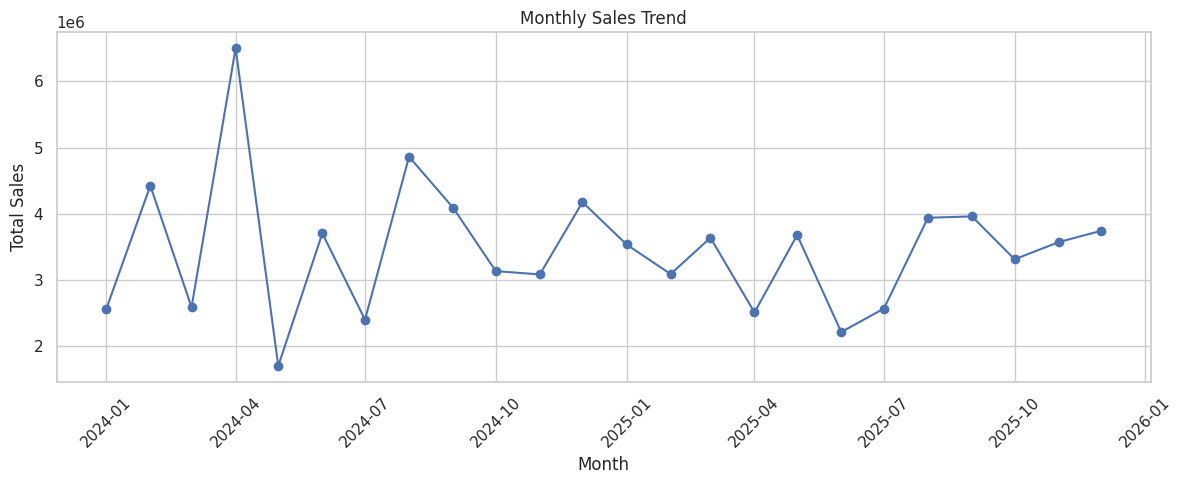

In [ ]:
monthly_sales = df.groupby(
    ["Year", "Month_Number"]
)["Sales"].sum().reset_index()

monthly_sales["Date"] = pd.to_datetime(
    monthly_sales["Year"].astype(str) + "-" +
    monthly_sales["Month_Number"].astype(str) + "-01"
)

monthly_sales = monthly_sales.sort_values("Date")

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["Date"], monthly_sales["Sales"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

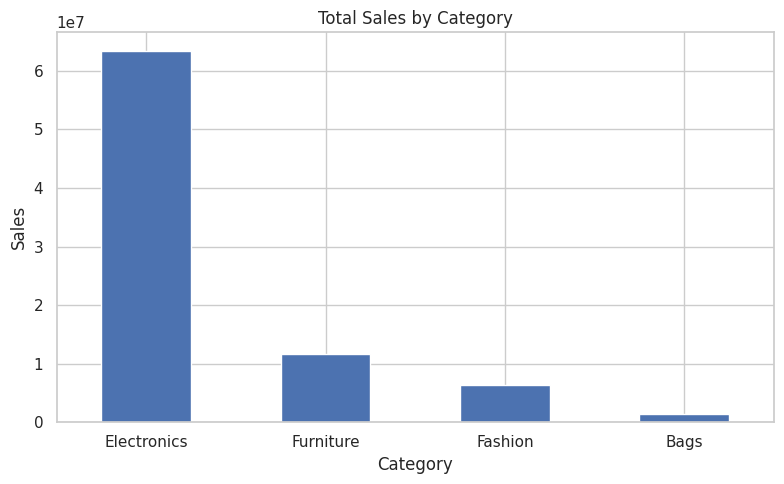

In [ ]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
category_sales.plot(kind="bar")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

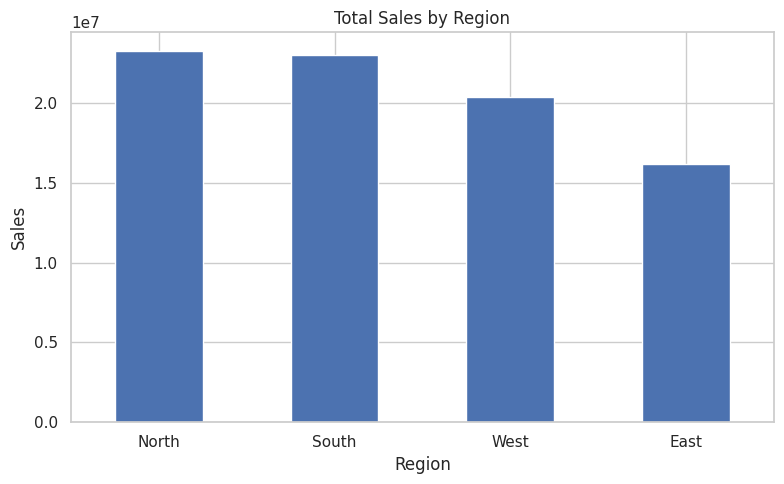

In [ ]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_sales.plot(kind="bar")
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

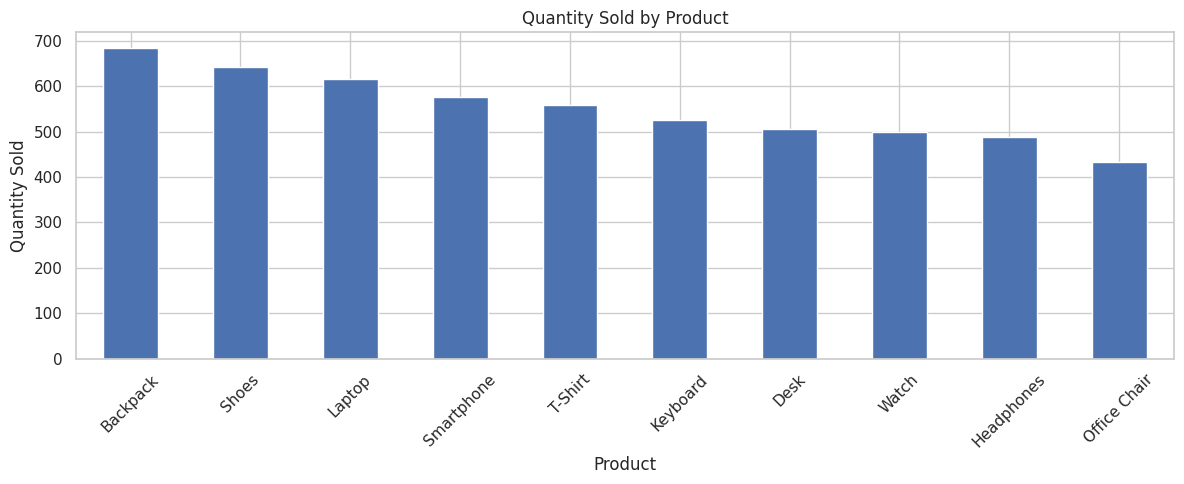

In [ ]:
product_quantity = df.groupby("Product_Name")["Quantity"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
product_quantity.plot(kind="bar")
plt.title("Quantity Sold by Product")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

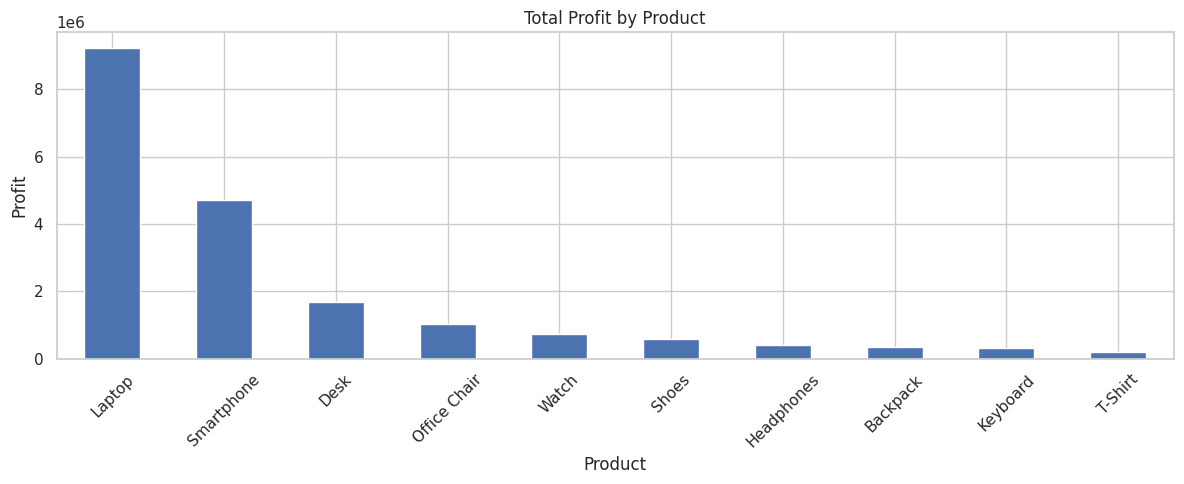

In [ ]:
product_profit = df.groupby("Product_Name")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
product_profit.plot(kind="bar")
plt.title("Total Profit by Product")
plt.xlabel("Product")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("===== SALES SUMMARY =====")
print("Total Sales:", round(df["Sales"].sum(), 2))
print("Total Profit:", round(df["Profit"].sum(), 2))
print("Total Quantity Sold:", df["Quantity"].sum())
print("Number of Products:", df["Product_Name"].nunique())
print("Number of Regions:", df["Region"].nunique())
print("Number of Orders:", df["Order_ID"].nunique())

===== SALES SUMMARY =====
Total Sales: 82912351.78
Total Profit: 19239837.09
Total Quantity Sold: 5526
Number of Products: 10
Number of Regions: 4
Number of Orders: 1000


In [ ]:
forecast_data = df.groupby("Order_Date").agg({
    "Sales": "sum",
    "Quantity": "sum",
    "Profit": "sum"
}).reset_index()

forecast_data = forecast_data.sort_values("Order_Date")

forecast_data.head()

,Order_Date,Sales,Quantity,Profit
0,2024-01-03,44478.96,14,8477.46
1,2024-01-04,28804.20,10,8285.16
2,2024-01-05,587964.80,14,138314.28
3,2024-01-06,161434.94,6,24995.96
4,2024-01-07,48979.59,16,9189.72


In [ ]:
# Make a copy of the daily sales data
forecast_data = df.groupby("Order_Date").agg({
    "Sales": "sum",
    "Quantity": "sum",
    "Profit": "sum"
}).reset_index()

forecast_data = forecast_data.sort_values("Order_Date").reset_index(drop=True)

# Calendar features
forecast_data["Year"] = forecast_data["Order_Date"].dt.year
forecast_data["Month"] = forecast_data["Order_Date"].dt.month
forecast_data["Day"] = forecast_data["Order_Date"].dt.day
forecast_data["Day_of_Week"] = forecast_data["Order_Date"].dt.dayofweek
forecast_data["Week_of_Year"] = forecast_data["Order_Date"].dt.isocalendar().week.astype(int)

# Lag features
forecast_data["Previous_Day_Sales"] = forecast_data["Sales"].shift(1)
forecast_data["Previous_7_Day_Sales"] = forecast_data["Sales"].shift(7)

# Rolling average
forecast_data["7_Day_Average_Sales"] = (
    forecast_data["Sales"].shift(1).rolling(window=7).mean()
)

# Remove rows created by lag/rolling calculations
forecast_data = forecast_data.dropna().reset_index(drop=True)

print("Forecasting dataset shape:", forecast_data.shape)
forecast_data.head()

Forecasting dataset shape: (531, 12)


,Order_Date,Sales,Quantity,Profit,Year,Month,Day,Day_of_Week,Week_of_Year,Previous_Day_Sales,Previous_7_Day_Sales,7_Day_Average_Sales
0,2024-01-11,56063.46,16,11564.77,2024,1,11,3,2,48824.67,44478.96,163391.521429
1,2024-01-12,57848.46,13,10741.45,2024,1,12,4,2,56063.46,28804.20,165046.450000
2,2024-01-13,29391.66,7,10080.56,2024,1,13,5,2,57848.46,587964.80,169195.630000
3,2024-01-14,3627.29,2,1136.45,2024,1,14,6,2,29391.66,161434.94,89399.467143
4,2024-01-15,391848.16,10,81187.42,2024,1,15,0,3,3627.29,48979.59,66855.517143


In [ ]:
features = [
    "Year",
    "Month",
    "Day",
    "Day_of_Week",
    "Week_of_Year",
    "Previous_Day_Sales",
    "Previous_7_Day_Sales",
    "7_Day_Average_Sales"
]

X = forecast_data[features]
y = forecast_data["Sales"]

print("Input features:")
print(X.columns.tolist())

print("\nTarget:")
print("Sales")

Input features:
['Year', 'Month', 'Day', 'Day_of_Week', 'Week_of_Year', 'Previous_Day_Sales', 'Previous_7_Day_Sales', '7_Day_Average_Sales']

Target:
Sales


In [ ]:
split_index = int(len(forecast_data) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 424
Testing records: 107


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=10
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:10])

Predictions generated successfully!
[114875.46462568 138252.01972278 162246.73093837 165757.00862977
 120150.87795692 161488.33980202 167220.18053128 144065.41348045
 161743.78544873 128988.65834082]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("===== MODEL PERFORMANCE =====")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))

===== MODEL PERFORMANCE =====
MAE : 175423.13
RMSE: 237620.97
R² Score: -0.0641


In [ ]:
results = pd.DataFrame({
    "Date": forecast_data.iloc[split_index:]["Order_Date"].values,
    "Actual_Sales": y_test.values,
    "Predicted_Sales": y_pred
})

results.head(10)

,Date,Actual_Sales,Predicted_Sales
0,2025-08-04,9942.60,114875.464626
1,2025-08-06,470464.12,138252.019723
2,2025-08-07,242598.50,162246.730938
3,2025-08-09,114461.37,165757.008630
4,2025-08-10,406027.80,120150.877957
5,2025-08-11,468941.08,161488.339802
6,2025-08-12,84748.24,167220.180531
7,2025-08-13,495983.37,144065.413480
8,2025-08-14,7050.24,161743.785449
9,2025-08-15,123577.55,128988.658341


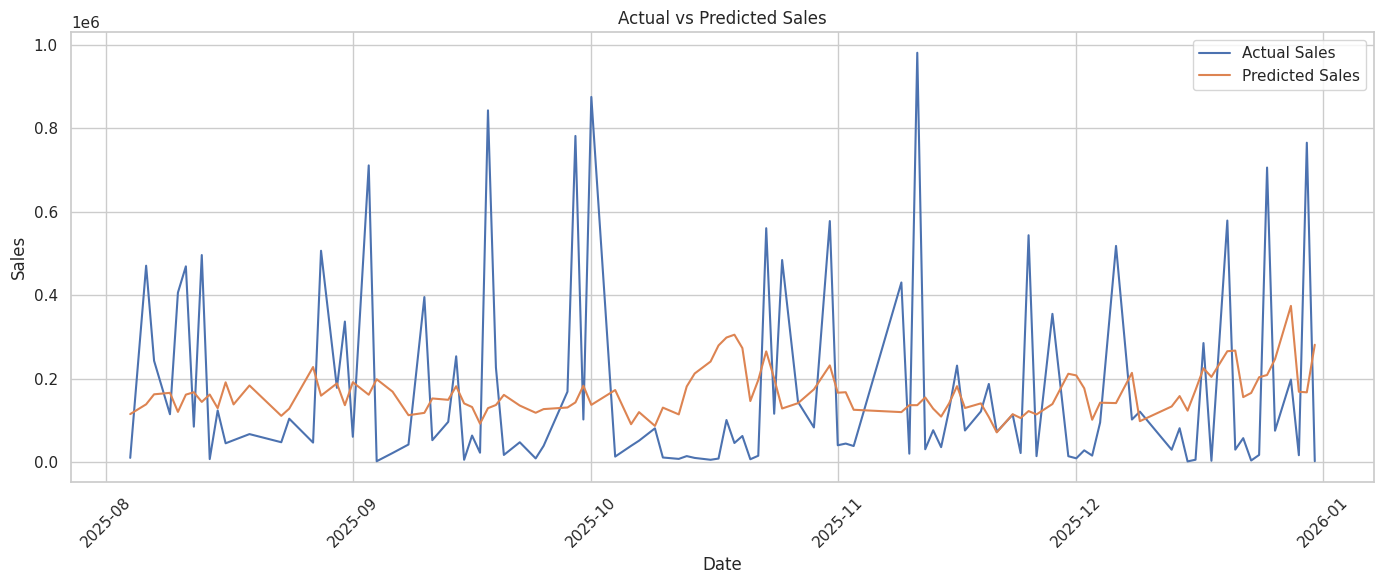

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    results["Date"],
    results["Actual_Sales"],
    label="Actual Sales"
)

plt.plot(
    results["Date"],
    results["Predicted_Sales"],
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

                Feature  Importance
5    Previous_Day_Sales    0.219994
7   7_Day_Average_Sales    0.207482
6  Previous_7_Day_Sales    0.185178
2                   Day    0.136162
4          Week_of_Year    0.109016
3           Day_of_Week    0.082701
1                 Month    0.043704
0                  Year    0.015762


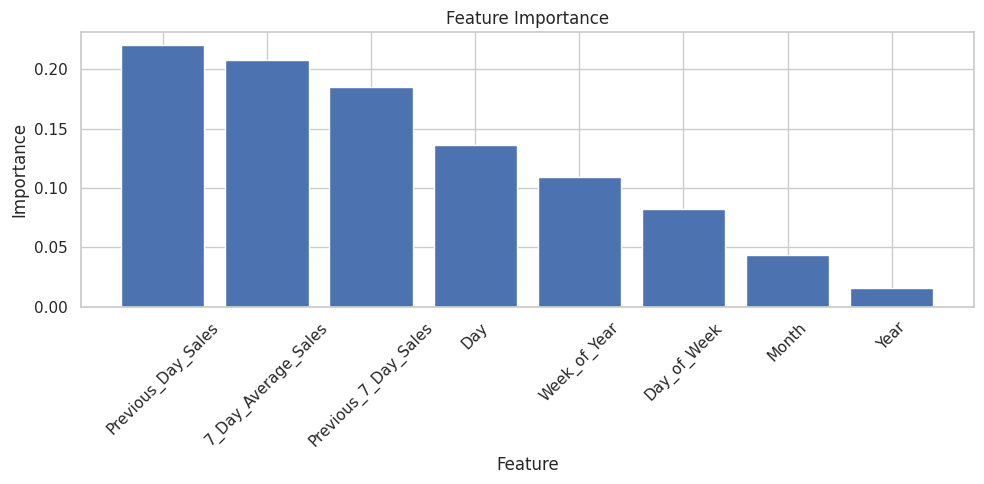

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Get the latest date in our dataset
last_date = forecast_data["Order_Date"].max()

print("Last available date:", last_date)

Last available date: 2025-12-31 00:00:00


In [ ]:
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

future_data = pd.DataFrame({
    "Order_Date": future_dates
})

future_data.head()

,Order_Date
0,2026-01-01
1,2026-01-02
2,2026-01-03
3,2026-01-04
4,2026-01-05


In [ ]:
future_data["Year"] = future_data["Order_Date"].dt.year
future_data["Month"] = future_data["Order_Date"].dt.month
future_data["Day"] = future_data["Order_Date"].dt.day
future_data["Day_of_Week"] = future_data["Order_Date"].dt.dayofweek
future_data["Week_of_Year"] = future_data["Order_Date"].dt.isocalendar().week.astype(int)

# Use the latest known sales information
last_sales = forecast_data["Sales"].iloc[-1]

last_7_days_average = forecast_data["Sales"].tail(7).mean()

future_data["Previous_Day_Sales"] = last_sales
future_data["Previous_7_Day_Sales"] = last_7_days_average
future_data["7_Day_Average_Sales"] = last_7_days_average

future_data.head()

,Order_Date,Year,Month,Day,Day_of_Week,Week_of_Year,Previous_Day_Sales,Previous_7_Day_Sales,7_Day_Average_Sales
0,2026-01-01,2026,1,1,3,1,1985.53,254123.888571,254123.888571
1,2026-01-02,2026,1,2,4,1,1985.53,254123.888571,254123.888571
2,2026-01-03,2026,1,3,5,1,1985.53,254123.888571,254123.888571
3,2026-01-04,2026,1,4,6,1,1985.53,254123.888571,254123.888571
4,2026-01-05,2026,1,5,0,2,1985.53,254123.888571,254123.888571


In [ ]:
future_X = future_data[features]

future_predictions = model.predict(future_X)

future_data["Predicted_Sales"] = future_predictions

future_data[["Order_Date", "Predicted_Sales"]].head(10)

,Order_Date,Predicted_Sales
0,2026-01-01,218134.544276
1,2026-01-02,233305.231319
2,2026-01-03,230676.062934
3,2026-01-04,219966.047631
4,2026-01-05,200733.540326
5,2026-01-06,183919.893053
6,2026-01-07,154428.520856
7,2026-01-08,153157.346291
8,2026-01-09,156530.479438
9,2026-01-10,158303.861595


In [ ]:
future_results = future_data[
    ["Order_Date", "Predicted_Sales"]
].copy()

future_results["Predicted_Sales"] = future_results["Predicted_Sales"].round(2)

future_results

,Order_Date,Predicted_Sales
0,2026-01-01,218134.54
1,2026-01-02,233305.23
2,2026-01-03,230676.06
3,2026-01-04,219966.05
4,2026-01-05,200733.54
5,2026-01-06,183919.89
6,2026-01-07,154428.52
7,2026-01-08,153157.35
8,2026-01-09,156530.48
9,2026-01-10,158303.86


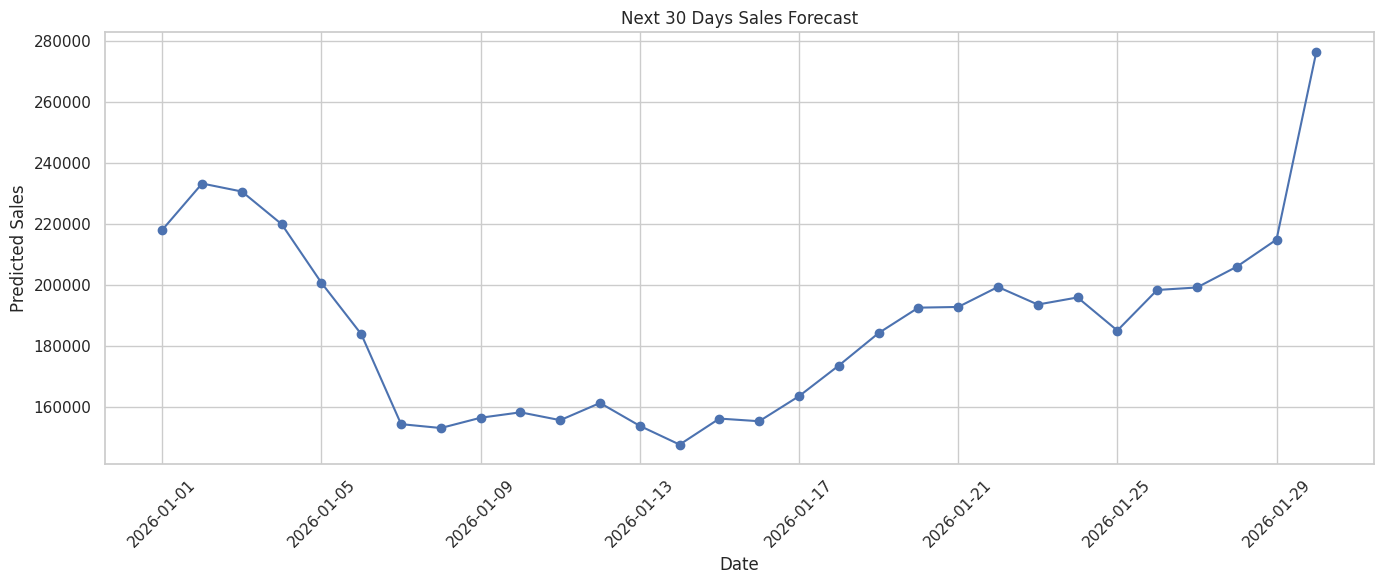

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    future_results["Order_Date"],
    future_results["Predicted_Sales"],
    marker="o"
)

plt.title("Next 30 Days Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
total_predicted_sales = future_data["Predicted_Sales"].sum()
average_daily_sales = future_data["Predicted_Sales"].mean()

print("===== FUTURE SALES FORECAST =====")
print("Forecast Period: 30 Days")
print("Expected Total Sales:", round(total_predicted_sales, 2))
print("Expected Average Daily Sales:", round(average_daily_sales, 2))

===== FUTURE SALES FORECAST =====
Forecast Period: 30 Days
Expected Total Sales: 5615551.67
Expected Average Daily Sales: 187185.06


In [ ]:
# Calculate total quantity sold for each product
product_demand = df.groupby("Product_Name").agg({
    "Quantity": "sum",
    "Sales": "sum"
}).reset_index()

product_demand.columns = [
    "Product_Name",
    "Total_Quantity_Sold",
    "Total_Sales"
]

product_demand

,Product_Name,Total_Quantity_Sold,Total_Sales
0,Backpack,684,1423384.15
1,Desk,505,7310771.66
2,Headphones,488,1797842.82
3,Keyboard,526,1338873.50
4,Laptop,615,39242885.91
5,Office Chair,432,4397451.97
6,Shoes,642,2470662.38
7,Smartphone,576,21023527.21
8,T-Shirt,558,785711.40
9,Watch,500,3121240.78


In [ ]:
# Number of days in the historical dataset
total_days = (
    df["Order_Date"].max() - df["Order_Date"].min()
).days + 1

product_demand["Average_Daily_Demand"] = (
    product_demand["Total_Quantity_Sold"] / total_days
)

product_demand["Average_Daily_Demand"] = (
    product_demand["Average_Daily_Demand"].round(2)
)

product_demand

,Product_Name,Total_Quantity_Sold,Total_Sales,Average_Daily_Demand
0,Backpack,684,1423384.15,0.94
1,Desk,505,7310771.66,0.69
2,Headphones,488,1797842.82,0.67
3,Keyboard,526,1338873.50,0.72
4,Laptop,615,39242885.91,0.84
5,Office Chair,432,4397451.97,0.59
6,Shoes,642,2470662.38,0.88
7,Smartphone,576,21023527.21,0.79
8,T-Shirt,558,785711.40,0.77
9,Watch,500,3121240.78,0.69


In [ ]:
np.random.seed(42)

product_demand["Current_Stock"] = np.random.randint(
    20, 150, size=len(product_demand)
)

product_demand

,Product_Name,Total_Quantity_Sold,Total_Sales,Average_Daily_Demand,Current_Stock
0,Backpack,684,1423384.15,0.94,122
1,Desk,505,7310771.66,0.69,112
2,Headphones,488,1797842.82,0.67,34
3,Keyboard,526,1338873.50,0.72,126
4,Laptop,615,39242885.91,0.84,91
5,Office Chair,432,4397451.97,0.59,40
6,Shoes,642,2470662.38,0.88,122
7,Smartphone,576,21023527.21,0.79,141
8,T-Shirt,558,785711.40,0.77,94
9,Watch,500,3121240.78,0.69,107


In [ ]:
product_demand["Monthly_Demand"] = (
    product_demand["Average_Daily_Demand"] * 30
)

product_demand["Safety_Stock"] = (
    product_demand["Monthly_Demand"] * 0.20
).round().astype(int)

product_demand

,Product_Name,Total_Quantity_Sold,Total_Sales,Average_Daily_Demand,Current_Stock,Monthly_Demand,Safety_Stock
0,Backpack,684,1423384.15,0.94,122,28.2,6
1,Desk,505,7310771.66,0.69,112,20.7,4
2,Headphones,488,1797842.82,0.67,34,20.1,4
3,Keyboard,526,1338873.50,0.72,126,21.6,4
4,Laptop,615,39242885.91,0.84,91,25.2,5
5,Office Chair,432,4397451.97,0.59,40,17.7,4
6,Shoes,642,2470662.38,0.88,122,26.4,5
7,Smartphone,576,21023527.21,0.79,141,23.7,5
8,T-Shirt,558,785711.40,0.77,94,23.1,5
9,Watch,500,3121240.78,0.69,107,20.7,4


In [ ]:
lead_time_days = 7

product_demand["Reorder_Point"] = (
    product_demand["Average_Daily_Demand"] *
    lead_time_days
    + product_demand["Safety_Stock"]
).round().astype(int)

product_demand

,Product_Name,Total_Quantity_Sold,Total_Sales,Average_Daily_Demand,Current_Stock,Monthly_Demand,Safety_Stock,Reorder_Point
0,Backpack,684,1423384.15,0.94,122,28.2,6,13
1,Desk,505,7310771.66,0.69,112,20.7,4,9
2,Headphones,488,1797842.82,0.67,34,20.1,4,9
3,Keyboard,526,1338873.50,0.72,126,21.6,4,9
4,Laptop,615,39242885.91,0.84,91,25.2,5,11
5,Office Chair,432,4397451.97,0.59,40,17.7,4,8
6,Shoes,642,2470662.38,0.88,122,26.4,5,11
7,Smartphone,576,21023527.21,0.79,141,23.7,5,11
8,T-Shirt,558,785711.40,0.77,94,23.1,5,10
9,Watch,500,3121240.78,0.69,107,20.7,4,9


In [ ]:
product_demand["Recommended_Order"] = (
    product_demand["Reorder_Point"]
    - product_demand["Current_Stock"]
)

product_demand["Recommended_Order"] = (
    product_demand["Recommended_Order"].clip(lower=0)
)

product_demand

,Product_Name,Total_Quantity_Sold,Total_Sales,Average_Daily_Demand,Current_Stock,Monthly_Demand,Safety_Stock,Reorder_Point,Recommended_Order
0,Backpack,684,1423384.15,0.94,122,28.2,6,13,0
1,Desk,505,7310771.66,0.69,112,20.7,4,9,0
2,Headphones,488,1797842.82,0.67,34,20.1,4,9,0
3,Keyboard,526,1338873.50,0.72,126,21.6,4,9,0
4,Laptop,615,39242885.91,0.84,91,25.2,5,11,0
5,Office Chair,432,4397451.97,0.59,40,17.7,4,8,0
6,Shoes,642,2470662.38,0.88,122,26.4,5,11,0
7,Smartphone,576,21023527.21,0.79,141,23.7,5,11,0
8,T-Shirt,558,785711.40,0.77,94,23.1,5,10,0
9,Watch,500,3121240.78,0.69,107,20.7,4,9,0


In [ ]:
def inventory_status(row):
    if row["Current_Stock"] <= row["Reorder_Point"]:
        return "REORDER"
    elif row["Current_Stock"] <= row["Reorder_Point"] * 1.25:
        return "LOW STOCK"
    else:
        return "SUFFICIENT"

product_demand["Inventory_Status"] = product_demand.apply(
    inventory_status,
    axis=1
)

product_demand

,Product_Name,Total_Quantity_Sold,Total_Sales,Average_Daily_Demand,Current_Stock,Monthly_Demand,Safety_Stock,Reorder_Point,Recommended_Order,Inventory_Status
0,Backpack,684,1423384.15,0.94,122,28.2,6,13,0,SUFFICIENT
1,Desk,505,7310771.66,0.69,112,20.7,4,9,0,SUFFICIENT
2,Headphones,488,1797842.82,0.67,34,20.1,4,9,0,SUFFICIENT
3,Keyboard,526,1338873.50,0.72,126,21.6,4,9,0,SUFFICIENT
4,Laptop,615,39242885.91,0.84,91,25.2,5,11,0,SUFFICIENT
5,Office Chair,432,4397451.97,0.59,40,17.7,4,8,0,SUFFICIENT
6,Shoes,642,2470662.38,0.88,122,26.4,5,11,0,SUFFICIENT
7,Smartphone,576,21023527.21,0.79,141,23.7,5,11,0,SUFFICIENT
8,T-Shirt,558,785711.40,0.77,94,23.1,5,10,0,SUFFICIENT
9,Watch,500,3121240.78,0.69,107,20.7,4,9,0,SUFFICIENT


In [ ]:
inventory_report = product_demand[
    [
        "Product_Name",
        "Average_Daily_Demand",
        "Current_Stock",
        "Safety_Stock",
        "Reorder_Point",
        "Recommended_Order",
        "Inventory_Status"
    ]
]

inventory_report

,Product_Name,Average_Daily_Demand,Current_Stock,Safety_Stock,Reorder_Point,Recommended_Order,Inventory_Status
0,Backpack,0.94,122,6,13,0,SUFFICIENT
1,Desk,0.69,112,4,9,0,SUFFICIENT
2,Headphones,0.67,34,4,9,0,SUFFICIENT
3,Keyboard,0.72,126,4,9,0,SUFFICIENT
4,Laptop,0.84,91,5,11,0,SUFFICIENT
5,Office Chair,0.59,40,4,8,0,SUFFICIENT
6,Shoes,0.88,122,5,11,0,SUFFICIENT
7,Smartphone,0.79,141,5,11,0,SUFFICIENT
8,T-Shirt,0.77,94,5,10,0,SUFFICIENT
9,Watch,0.69,107,4,9,0,SUFFICIENT


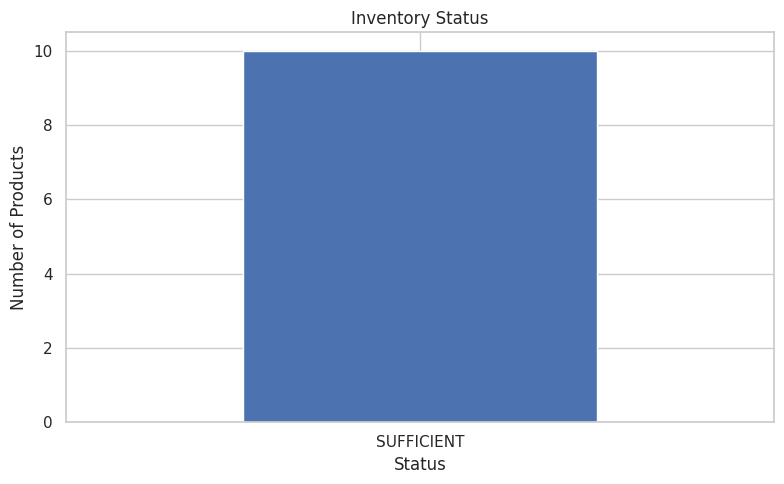

In [ ]:
status_counts = product_demand["Inventory_Status"].value_counts()

plt.figure(figsize=(8, 5))

status_counts.plot(kind="bar")

plt.title("Inventory Status")
plt.xlabel("Status")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

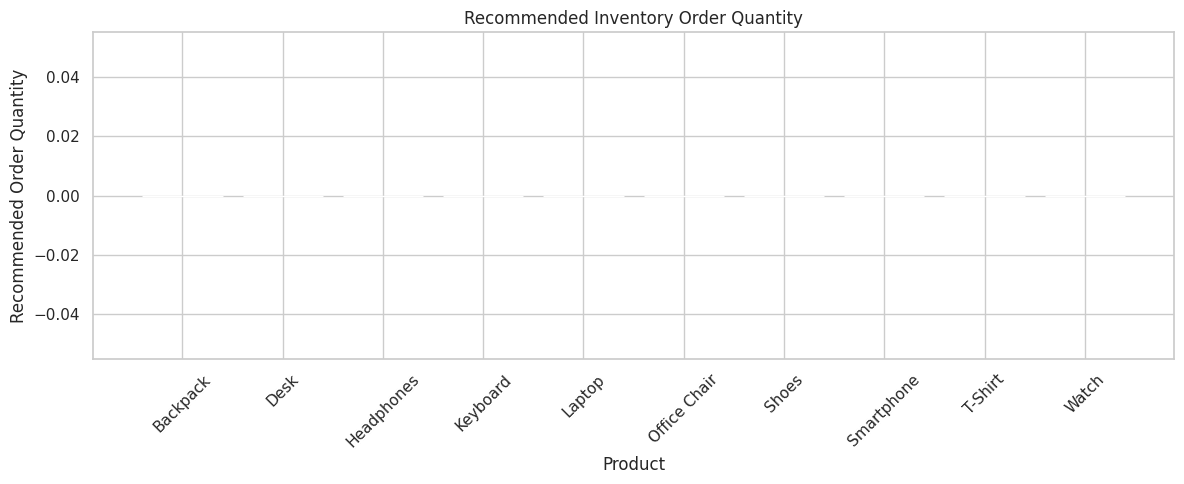

In [ ]:
plt.figure(figsize=(12, 5))

plt.bar(
    product_demand["Product_Name"],
    product_demand["Recommended_Order"]
)

plt.title("Recommended Inventory Order Quantity")
plt.xlabel("Product")
plt.ylabel("Recommended Order Quantity")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
output_file = "Retail_Inventory_Optimization_Report.xlsx"

inventory_report.to_excel(
    output_file,
    index=False
)

files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Create a clean inventory report for the dashboard

dashboard_data = product_demand[
    [
        "Product_Name",
        "Average_Daily_Demand",
        "Current_Stock",
        "Safety_Stock",
        "Reorder_Point",
        "Recommended_Order",
        "Inventory_Status"
    ]
].copy()

dashboard_data

,Product_Name,Average_Daily_Demand,Current_Stock,Safety_Stock,Reorder_Point,Recommended_Order,Inventory_Status
0,Backpack,0.94,122,6,13,0,SUFFICIENT
1,Desk,0.69,112,4,9,0,SUFFICIENT
2,Headphones,0.67,34,4,9,0,SUFFICIENT
3,Keyboard,0.72,126,4,9,0,SUFFICIENT
4,Laptop,0.84,91,5,11,0,SUFFICIENT
5,Office Chair,0.59,40,4,8,0,SUFFICIENT
6,Shoes,0.88,122,5,11,0,SUFFICIENT
7,Smartphone,0.79,141,5,11,0,SUFFICIENT
8,T-Shirt,0.77,94,5,10,0,SUFFICIENT
9,Watch,0.69,107,4,9,0,SUFFICIENT


In [ ]:
dashboard_file = "inventory_dashboard_data.csv"

dashboard_data.to_csv(
    dashboard_file,
    index=False
)

print("Dashboard data saved successfully!")

Dashboard data saved successfully!


In [54]:
dashboard_data = product_demand[
    [
        "Product_Name",
        "Average_Daily_Demand",
        "Current_Stock",
        "Safety_Stock",
        "Reorder_Point",
        "Recommended_Order",
        "Inventory_Status"
    ]
].copy()

dashboard_data.to_csv(
    "inventory_dashboard_data.csv",
    index=False
)

print("CSV file created successfully!")

CSV file created successfully!


In [55]:
from google.colab import files

files.download("inventory_dashboard_data.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>